<a href="https://colab.research.google.com/github/paulsubarna/CONFEDMADE/blob/main/tutorial_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### TUTORIAL 4: REPLAY BUFFERS IN SEQUENTIAL TRAINING

In this notebook, we will explore different replay buffer strategies. The two most common approaches are as follows:
- Gnerative Replay buffer using VAEs- "Store generated samples"
- Experience Replay- "Store real samples from the dataset"

We will try to investigate how does storing real samples and generated samples impact into the sequential training of our model.

# Hauptabhängigkeiten
pip install torch torchvision
pip install matplotlib
pip install tqdm
pip install numpy

# Optional (falls nicht bereits installiert)
pip install jupyter
pip install notebook

#### DATA Preparation and Loading

In [1]:
import torch
from torchvision import datasets
from torchvision import transforms
from tqdm import tqdm
from torchvision.models import resnet18 # Not explicitly used, but good to have if planning to switch to ResNet
import random
import matplotlib.pyplot as plt

import torchvision.datasets as datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models # For potentially using pretrained models
import torchvision
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import os # For creating directories
import numpy as np # For numerical operations, like in replay buffer calculations

# Define mean and std for MNIST if normalization beyond ToTensor() was desired.
# For MNIST, ToTensor() already scales images to [0,1]. Further normalization can sometimes help.
# These values are typical for ImageNet, not MNIST. For MNIST, mean is ~0.1307 and std is ~0.3081 for single channel.
# mean = torch.tensor([0.4589, 0.4384, 0.4011]) # Example for 3-channel images
# std = torch.tensor([0.2793, 0.2724, 0.2835]) # Example for 3-channel images

# Define a simple transform to convert images to tensors.
# MNIST images are grayscale, so they will be (1, H, W) tensors.
transform_mnist = transforms.Compose([
    transforms.ToTensor() # Converts a PIL Image or numpy.ndarray to tensor and scales an image in the range [0., 1.]
    # transforms.Normalize((0.1307,), (0.3081,)) # Optional: Normalize with MNIST mean and std if desired
])

# Download and load the MNIST training dataset.
# root: directory where the data will be stored.
# train=True: specifies that this is the training set.
# download=True: downloads the dataset if not already present in the root directory.
# transform: applies the defined transformations to the dataset images.
mnist_trainset = datasets.MNIST(root='./data/Mnist', train=True, download=True, transform=transform_mnist)
# Download and load the MNIST test dataset.
mnist_testset = datasets.MNIST(root='./data/Mnist', train=False, download=True, transform=transform_mnist)

# Print the number of samples in the training and test sets.
print(f"Number of training samples: {len(mnist_trainset)}") # Expected: 60000
print(f"Number of test samples: {len(mnist_testset)}")     # Expected: 10000

# Configuration dictionary for MNIST dataset properties.
config = {'size': 28, 'channels': 1, 'classes': 10}

# Create directories for saving models if they don't exist.
# This helps in organizing saved model checkpoints.
if not os.path.exists('./model_replay'):
    os.makedirs('./model_replay')
if not os.path.exists('./vae_models'):
    os.makedirs('./vae_models')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.34MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 297kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.39MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Number of training samples: 60000
Number of test samples: 10000


### Spliting dataset into N contexts

- Let us first divide our dataset into five sequential tasks and we will do it based on the labels
- Split with labels such that,  context 1: [0,1], context 2: [2,3],  context 1: [4,5], context 2: [6,7],  context 1: [8,9]

In [2]:
# Initialize lists to store training and test data for each context (task).
train_data_cl = [] # cl stands for Continual Learning
test_data_cl = []

# Define the labels for each of the 5 contexts for the training set.
# Each sublist represents a task, containing the class labels for that task.
labels_per_context_train = [[0,1], [2,3], [4,5], [6,7], [8,9]]

# Define the labels for each of the 5 contexts for the test set.
# For continual learning evaluation, the test set for a given task usually includes all classes seen so far.
labels_per_context_test = [
    [0,1],                             # Test on classes from context 0
    [0,1,2,3],                         # Test on classes from context 0 & 1
    [0,1,2,3,4,5],                     # Test on classes from context 0, 1 & 2
    [0,1,2,3,4,5,6,7],                 # Test on classes from context 0, 1, 2 & 3
    [0,1,2,3,4,5,6,7,8,9]              # Test on all classes (after all contexts)
]

# Iterate over the number of contexts (which is 5).
num_contexts = 5
for j in range(num_contexts):
    # Append an empty list for the current context's training data.
    train_data_cl.append([])
    # Append an empty list for the current context's test data.
    test_data_cl.append([])

    # Populate the training data for the current context j.
    # Iterate through the entire original MNIST training set.
    for i in range(len(mnist_trainset)):
        # mnist_trainset[i] returns a tuple (image_tensor, label).
        # Check if the label of the current sample is in the list of labels for the current training context.
        if mnist_trainset[i][1] in labels_per_context_train[j]:
            # If it is, add the (image, label) tuple to the current context's training data list.
            train_data_cl[j].append((mnist_trainset[i][0], mnist_trainset[i][1]))

    # Populate the test data for the current context j.
    # Iterate through the entire original MNIST test set.
    for i in range(len(mnist_testset)):
        # Check if the label of the current sample is in the list of labels for the current test context.
        if mnist_testset[i][1] in labels_per_context_test[j]:
            # If it is, add the (image, label) tuple to the current context's test data list.
            test_data_cl[j].append((mnist_testset[i][0], mnist_testset[i][1]))

# Example: Print the number of samples in the first training context and first test context.
print(f"Samples in training context 0: {len(train_data_cl[0])}")
print(f"Samples in test context 0: {len(test_data_cl[0])}")
print(f"Samples in training context 4: {len(train_data_cl[4])}")
print(f"Samples in test context 4: {len(test_data_cl[4])}")

# You can inspect an element like this:
# print(train_data_cl[0][0]) # This would show the first image tensor and its label from the first training context.

Samples in training context 0: 12665
Samples in test context 0: 2115
Samples in training context 4: 11800
Samples in test context 4: 10000


#### Sequential training

Let us now use this set of tasks to train a neural network sequentially, where we define a simple classifier or convolutational networks and train it on all the sequence of tasks  

"" TO-DO ""
- Define a simple MLP network or a Convolutional Network
- Define your training loop
- Train it on all the contexts

In [3]:
# Define the Classifier model as a Convolutional Neural Network (CNN).
class Classifier(nn.Module):
    # Constructor for the Classifier class.
    # hidden_dim: Number of units in the hidden linear layer.
    # output_dim: Number of output units, corresponding to the number of classes (10 for MNIST).
    def __init__(self, hidden_dim, output_dim):
        super(Classifier, self).__init__() # Call the constructor of the parent class (nn.Module).
        
        # First convolutional layer:
        # Takes 1 input channel (grayscale image).
        # Outputs 32 feature maps.
        # Kernel size is 3x3.
        # Stride is 1 (kernel moves one pixel at a time).
        # Padding is 1 (adds a 1-pixel border to the input, preserving dimensions with a 3x3 kernel).
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        # Second convolutional layer:
        # Takes 32 input channels (from conv1).
        # Outputs 64 feature maps.
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        # Max pooling layer:
        # Kernel size is 2x2.
        # Stride is 2 (downsamples the feature map by a factor of 2).
        # Padding is 0 (no padding).
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        
        # After two conv and pool layers, the image size (28x28) becomes:
        # conv1 (padding=1, kernel=3): 28x28 -> 28x28
        # pool1 (kernel=2, stride=2): 28x28 -> 14x14
        # conv2 (padding=1, kernel=3): 14x14 -> 14x14
        # pool2 (kernel=2, stride=2): 14x14 -> 7x7
        # The number of output channels from conv2 is 64.
        # So, the flattened size of the feature map is 64 * 7 * 7 = 3136.
        self.fc1_input_dim = 64 * 7 * 7
        
        # First fully connected (linear) layer.
        # Takes the flattened output from the convolutional layers.
        # Outputs 'hidden_dim' features.
        self.fc1 = nn.Linear(self.fc1_input_dim, hidden_dim)
        # Second fully connected (linear) layer.
        # Takes 'hidden_dim' features as input.
        # Outputs 'output_dim' features (logits for each class).
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        
        # Activation function (ReLU - Rectified Linear Unit).
        self.relu = nn.ReLU()

    # Defines the forward pass of the network.
    # x: input tensor (batch of images).
    def forward(self, x):
        # Apply first convolution, then ReLU, then pooling.
        x = self.pool(self.relu(self.conv1(x)))
        # Apply second convolution, then ReLU, then pooling.
        x = self.pool(self.relu(self.conv2(x)))
        
        # Flatten the output from the convolutional layers before passing to the fully connected layers.
        # x.view(-1, self.fc1_input_dim) reshapes x into (batch_size, fc1_input_dim).
        x = x.view(-1, self.fc1_input_dim)
        
        # Apply first fully connected layer, then ReLU.
        x = self.relu(self.fc1(x))
        # Apply second fully connected layer (output layer).
        # No activation function here because CrossEntropyLoss (used later) expects raw logits.
        x = self.fc2(x)
        return x

# Function to train the classifier model.
def train_classifier(model, train_data, test_data, num_epochs=10, batch_size=32, learning_rate=0.001):
    # Define loss function: CrossEntropyLoss is common for multi-class classification.
    # It combines LogSoftmax and NLLLoss in one single class.
    criterion = nn.CrossEntropyLoss()
    # Define optimizer: SGD (Stochastic Gradient Descent) is a classic optimizer.
    # model.parameters() provides all trainable parameters of the model to the optimizer.
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # Create DataLoader for the training data.
    # DataLoader handles batching, shuffling, and parallel data loading.
    # shuffle=True: shuffles the training data at every epoch to prevent model from learning order.
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
    # Create DataLoader for the test data.
    # shuffle=False: no need to shuffle test data.
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

    # Training loop: iterates for a specified number of epochs.
    for epoch in range(num_epochs):
        model.train() # Set the model to training mode (enables dropout, batch norm updates, etc.).
        running_loss = 0.0 # Variable to accumulate loss over batches.
        
        # Iterate over batches of training data.
        # tqdm provides a progress bar for the loop.
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training"):
            optimizer.zero_grad() # Zero out gradients from the previous iteration.
            
            outputs = model(inputs) # Perform a forward pass: get model predictions for the inputs.
            loss = criterion(outputs, labels) # Calculate the loss between predictions and actual labels.
            
            loss.backward() # Perform a backward pass: compute gradients of the loss w.r.t. model parameters.
            optimizer.step() # Update model parameters using the computed gradients.
            
            running_loss += loss.item() # Add the current batch's loss to the total loss for the epoch.

        # Print the average loss for the current epoch.
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

    # Evaluation loop after training is complete for the current call.
    model.eval() # Set the model to evaluation mode (disables dropout, uses running averages for batch norm, etc.).
    correct = 0 # Counter for correctly classified samples.
    total = 0   # Counter for total samples processed.
    with torch.no_grad(): # Disable gradient calculations during evaluation to save memory and computation.
        for inputs, labels in tqdm(test_loader, desc="Evaluating"):
            outputs = model(inputs) # Get model predictions.
            # torch.max returns (values, indices) of the maximum elements.
            # We are interested in the indices (predicted class labels).
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0) # Increment total samples by the batch size.
            # Increment correct predictions by comparing predicted labels with actual labels.
            correct += (predicted == labels).sum().item()

    # Print the accuracy of the model on the test data for this specific training call.
    print(f"Accuracy on the provided test data: {100 * correct / total:.2f}%")


# Define the model instance.
# hidden_dim=256: size of the hidden layer in the FC part.
# output_dim=10: 10 classes for MNIST digits.
model_no_replay = Classifier(hidden_dim=256, output_dim=10)

# Train the model sequentially on each context without any replay strategy.
print("--- Training Classifier Sequentially (No Replay) ---")
for i in range(num_contexts):
    print(f"\nTraining on Context {i} (Labels: {labels_per_context_train[i]}) ")
    # Train the model using the training data of the current context (train_data_cl[i])
    # and evaluate it on the test data specific to this context's cumulative knowledge (test_data_cl[i]).
    train_classifier(model_no_replay, train_data_cl[i], test_data_cl[i], num_epochs=5, batch_size=32, learning_rate=0.01)
    # Optionally save the model state after training on each context.
    # torch.save(model_no_replay.state_dict(), f'./model_replay/no_replay_context_{i}.pth')

--- Training Classifier Sequentially (No Replay) ---

Training on Context 0 (Labels: [0, 1]) 


Epoch 1/5 Training: 100%|██████████| 396/396 [00:03<00:00, 125.48it/s]


Epoch [1/5], Loss: 0.1896


Epoch 2/5 Training: 100%|██████████| 396/396 [00:02<00:00, 137.11it/s]


Epoch [2/5], Loss: 0.0149


...

Epoch [4/5], Loss: 0.0440


Epoch 5/5 Training: 100%|██████████| 369/369 [00:03<00:00, 121.82it/s]


Epoch [5/5], Loss: 0.0379


Evaluating: 100%|██████████| 313/313 [00:01<00:00, 277.24it/s]

Accuracy on the provided test data: 19.56%


We could clearly observe the phenomenon of catastrophic forgetting here.
We should also see the same phenomenon if we have to evaluate on individial contexts where the model performs the best on the last task and bad performance on the earlier tasks

In [4]:
# Function to evaluate the classifier model on a given test dataset.
def evaluate_classifier(model, context_id, test_data_for_eval, batch_size=32):
    # Create DataLoader for the test data.
    test_loader = torch.utils.data.DataLoader(test_data_for_eval, batch_size=batch_size, shuffle=False)

    # Set the model to evaluation mode.
    model.eval()
    correct = 0 # Counter for correctly classified samples.
    total = 0   # Counter for total samples processed.
    with torch.no_grad(): # Disable gradient calculations.
        for inputs, labels in tqdm(test_loader, desc=f"Evaluating on Context {context_id}"):
            outputs = model(inputs) # Get model predictions.
            _, predicted = torch.max(outputs.data, 1) # Get the predicted class labels.
            total += labels.size(0) # Increment total samples.
            correct += (predicted == labels).sum().item() # Increment correct predictions.

    accuracy = 100 * correct / total
    # Print the accuracy of the model on the provided test data.
    print(f"Accuracy of the model on test data for Context {context_id} (Labels: {labels_per_context_test[context_id]}): {accuracy:.2f}%")
    return accuracy

# Evaluate the final model (after training on all contexts without replay) on each context's specific test set.
# This helps to observe catastrophic forgetting: performance on earlier tasks might degrade significantly.
print("\n--- Evaluating Final Model (No Replay) on All Context Test Sets ---")
accuracies_no_replay = []
for i in range(num_contexts):
    # test_data_cl[i] contains test samples for classes seen up to context i.
    acc = evaluate_classifier(model_no_replay, i, test_data_cl[i], batch_size=32)
    accuracies_no_replay.append(acc)
print(f"\nAverage accuracy across all context evaluations (No Replay): {np.mean(accuracies_no_replay):.2f}%")


--- Evaluating Final Model (No Replay) on All Context Test Sets ---


Evaluating on Context 0: 100%|██████████| 67/67 [00:00<00:00, 293.86it/s]


Accuracy of the model on test data for Context 0 (Labels: [0, 1]): 0.00%


Evaluating on Context 1: 100%|██████████| 130/130 [00:00<00:00, 292.13it/s]


Accuracy of the model on test data for Context 1 (Labels: [0, 1, 2, 3]): 0.00%


...

Accuracy of the model on test data for Context 2 (Labels: [0, 1, 2, 3, 4, 5]): 0.00%


Evaluating on Context 3: 100%|██████████| 251/251 [00:00<00:00, 292.54it/s]


Accuracy of the model on test data for Context 3 (Labels: [0, 1, 2, 3, 4, 5, 6, 7]): 0.00%


Evaluating on Context 4: 100%|██████████| 313/313 [00:00<00:00, 319.87it/s]

Accuracy of the model on test data for Context 4 (Labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]): 19.56%

Average accuracy across all context evaluations (No Replay): 3.91%


#### Accomodate Replay buffers

We have two options
- Store generative samples using VAEs
- Store real samples as experience replay

But, first, we need to define our VAE model, train it on all the contexts and obderve its efficacy to generate new data

1. Generative Replay Buffers

- We will use VAE to generate new samples, that you will store in the memory buffers
- Define your VAE model
- we will generate samples based on class instances [0], [1], etc
- So, we will train our VAE model on samples from individual class instances. That means it is necessary to split the dataset based on the samples.

##### Split the dataset per labels

In [5]:
# Initialize lists to store training and test data for each individual digit (0-9).
# This is needed for training separate VAEs for each digit class.
train_data_per_digit = []
test_data_per_digit = []

# Define labels for each digit. Each sublist contains a single digit.
labels_for_vaes = [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9]]
num_digits = 10

# Iterate over each digit (0 to 9).
for j in range(num_digits):
    train_data_per_digit.append([])
    test_data_per_digit.append([])
    
    # Populate training data for the current digit j.
    for i in range(len(mnist_trainset)):
        if mnist_trainset[i][1] in labels_for_vaes[j]: # Check if the sample's label matches the current digit.
            train_data_per_digit[j].append((mnist_trainset[i][0], mnist_trainset[i][1]))
            
    # Populate test data for the current digit j.
    for i in range(len(mnist_testset)):
        if mnist_testset[i][1] in labels_for_vaes[j]: # Check if the sample's label matches the current digit.
            test_data_per_digit[j].append((mnist_testset[i][0], mnist_testset[i][1]))

# Example: Print the number of samples for digit 0 in its specific training and test sets.
print(f"Samples for digit 0 in its training set: {len(train_data_per_digit[0])}")
print(f"Samples for digit 0 in its test set: {len(test_data_per_digit[0])}")

# Inspect an element:
# print(train_data_per_digit[0][0]) # Shows the first image and label for digit 0.

Samples for digit 0 in its training set: 5923
Samples for digit 0 in its test set: 980


##### Variational Autoencoder

In [6]:
# Define the Encoder part of the VAE.
class Encoder(nn.Module):
    # Constructor.
    # input_dim: Dimensionality of the input data (e.g., 28*28 = 784 for flattened MNIST).
    # hidden_dim: Number of units in the hidden layer.
    # latent_dim: Dimensionality of the latent space (output of the encoder).
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        # First linear layer: input_dim -> hidden_dim.
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Second linear layer (outputs mean 'mu' of the latent distribution): hidden_dim -> latent_dim.
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        # Third linear layer (outputs log-variance 'logvar' of the latent distribution): hidden_dim -> latent_dim.
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.relu = nn.ReLU()

    # Forward pass for the encoder.
    # x: input tensor (batch of flattened images).
    def forward(self, x):
        # Flatten the input image if it's not already flat (e.g. coming directly from DataLoader).
        x = x.view(x.size(0), -1) # Reshape to (batch_size, input_dim)
        hidden = self.relu(self.fc1(x)) # Pass through the first linear layer and ReLU activation.
        mu = self.fc_mu(hidden)         # Compute mu.
        logvar = self.fc_logvar(hidden) # Compute logvar.
        return mu, logvar

# Define the Decoder part of the VAE.
class Decoder(nn.Module):
    # Constructor.
    # latent_dim: Dimensionality of the latent space (input to the decoder).
    # hidden_dim: Number of units in the hidden layer.
    # output_dim: Dimensionality of the reconstructed output (e.g., 784 for MNIST).
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        # First linear layer: latent_dim -> hidden_dim.
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        # Second linear layer: hidden_dim -> output_dim (reconstructed image dimensions).
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid() # Sigmoid activation to ensure output pixels are in [0,1].

    # Forward pass for the decoder.
    # z: latent vector (sample from the latent space).
    def forward(self, z):
        hidden = self.relu(self.fc1(z)) # Pass through the first linear layer and ReLU.
        # Pass through the second linear layer and Sigmoid to get reconstructed image.
        reconstruction = self.sigmoid(self.fc2(hidden))
        return reconstruction

# Define the Variational Autoencoder (VAE) model by combining Encoder and Decoder.
class VAE(nn.Module):
    # Constructor.
    # input_dim: Dimensionality of the input data.
    # hidden_dim: Number of units in the hidden layers of encoder/decoder.
    # latent_dim: Dimensionality of the latent space.
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim) # output_dim of decoder is input_dim of VAE

    # Reparameterization trick to allow backpropagation through a random sampling process.
    # mu: mean of the latent Gaussian.
    # logvar: log-variance of the latent Gaussian.
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar) # Calculate standard deviation from log-variance.
        eps = torch.randn_like(std)   # Generate random noise from a standard normal distribution.
        return mu + eps * std         # Return the sampled latent vector z.

    # Forward pass for the VAE.
    # x: input tensor (batch of images).
    def forward(self, x):
        original_shape = x.shape # Store original shape if input is not flattened
        x_flat = x.view(x.size(0), -1) # Flatten input for encoder
        mu, logvar = self.encoder(x_flat) # Get mu and logvar from the encoder.
        z = self.reparameterize(mu, logvar) # Sample latent vector z using reparameterization trick.
        x_recon_flat = self.decoder(z)      # Reconstruct the image from z using the decoder.
        # Reshape the reconstructed flat vector to the original image shape (e.g., 1x28x28 for MNIST)
        # Assuming input_dim corresponds to C*H*W, and decoder outputs flat vector.
        # For this VAE, input_dim is 784, so decoder output is 784. We need to reshape to (Batch, 1, 28, 28) for BCE loss with original image.
        # However, the loss_function below expects x_flat and x_recon_flat.
        return x_recon_flat, mu, logvar

    # VAE loss function: combines reconstruction loss and KL divergence.
    # x_flat: original flattened input data.
    # x_recon_flat: reconstructed flattened data.
    # mu: mean of the latent distribution.
    # logvar: log-variance of the latent distribution.
    def loss_function(self, x_flat, x_recon_flat, mu, logvar):
        # Reconstruction loss: Binary Cross-Entropy (BCE) is common for images with pixel values in [0,1].
        # F.binary_cross_entropy computes BCE loss. reduction='sum' sums the loss over all elements.
        BCE = F.binary_cross_entropy(x_recon_flat, x_flat, reduction='sum')
        
        # KL divergence: measures how much the learned distribution q(z|x) (encoded by mu, logvar)
        # diverges from the prior distribution p(z) (typically a standard Gaussian N(0,I)).
        # KLD = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        
        # Total loss is a weighted sum of BCE and KLD.
        # The weight for KLD (here, 1, as per common VAEs, notebook comment said 5*KLD, can be tuned) balances reconstruction quality and latent space regularization.
        return BCE + KLD # Using KLD_weight = 1, adjust if needed e.g. BCE + 5 * KLD

    # Method to generate samples from a given latent vector z.
    # z: a tensor of latent vectors.
    def sample(self, z):
        """ 
        1. Generate samples from the latent space (z is provided as input).
        2. Use the decoder to reconstruct the images.
        3. Return the reconstructed images, reshaped to image format.
        """
        with torch.no_grad(): # No need to track gradients during sampling.
            # Decode the latent vector z to get the reconstructed image (flattened).
            reconstructed_flat = self.decoder(z)
            # Reshape the flat reconstruction to the image format (e.g., batch_size, 1, 28, 28 for MNIST).
            return reconstructed_flat.view(-1, 1, config['size'], config['size'])
            
    # Method to generate new samples by sampling z from the prior (standard normal distribution).
    # num_samples: number of samples to generate.
    # latent_dim: dimensionality of the latent space (referred to as output_dim in the original notebook's generate call).
    def generate(self, num_samples, latent_dim):
        with torch.no_grad(): # No need to track gradients.
            # Sample random latent vectors z from a standard normal distribution N(0,I).
            # The shape of z will be (num_samples, latent_dim).
            z_random = torch.randn(num_samples, latent_dim)
            # Decode these random latent vectors to generate new image samples (flattened).
            samples_flat = self.decoder(z_random)
            # Reshape the generated flat samples to the image format.
            return samples_flat.view(-1, 1, config['size'], config['size'])

##### Train your VAE Model


--- Training VAEs for Each Digit ---

--- Training VAE for class/task 0 ---


VAE Epoch 1/10: 100%|██████████| 93/93 [00:00<00:00, 244.74it/s]


VAE Epoch 1, Average Loss: 222.1688


VAE Epoch 2/10: 100%|██████████| 93/93 [00:00<00:00, 218.05it/s]


VAE Epoch 2, Average Loss: 155.8364


...

VAE Epoch 9, Average Loss: 115.0746


VAE Epoch 10/10: 100%|██████████| 93/93 [00:00<00:00, 211.36it/s]


VAE Epoch 10, Average Loss: 113.7231
Saved VAE model for digit 0 to ./vae_models/vae_mnist_digit_0.pth


VAE Test for digit 0: 100%|██████████| 16/16 [00:00<00:00, 841.99it/s]


VAE Test Loss for digit 0: 113.1208


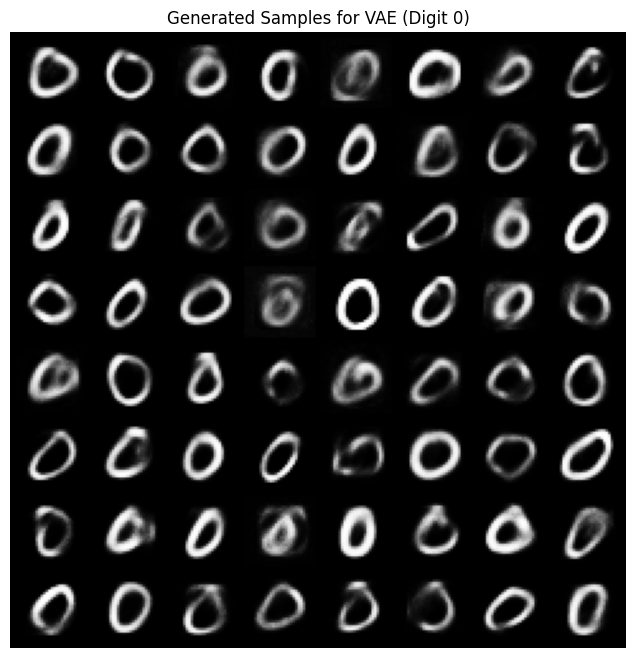


--- Training VAE for class/task 1 ---


VAE Epoch 1/10: 100%|██████████| 106/106 [00:00<00:00, 226.98it/s]


VAE Epoch 1, Average Loss: 132.4886


VAE Epoch 2/10: 100%|██████████| 106/106 [00:00<00:00, 245.37it/s]


VAE Epoch 2, Average Loss: 72.1430


...

VAE Epoch 9, Average Loss: 52.7713


VAE Epoch 10/10: 100%|██████████| 106/106 [00:00<00:00, 210.74it/s]


VAE Epoch 10, Average Loss: 52.0314
Saved VAE model for digit 1 to ./vae_models/vae_mnist_digit_1.pth


VAE Test for digit 1: 100%|██████████| 18/18 [00:00<00:00, 719.97it/s]


VAE Test Loss for digit 1: 50.8798


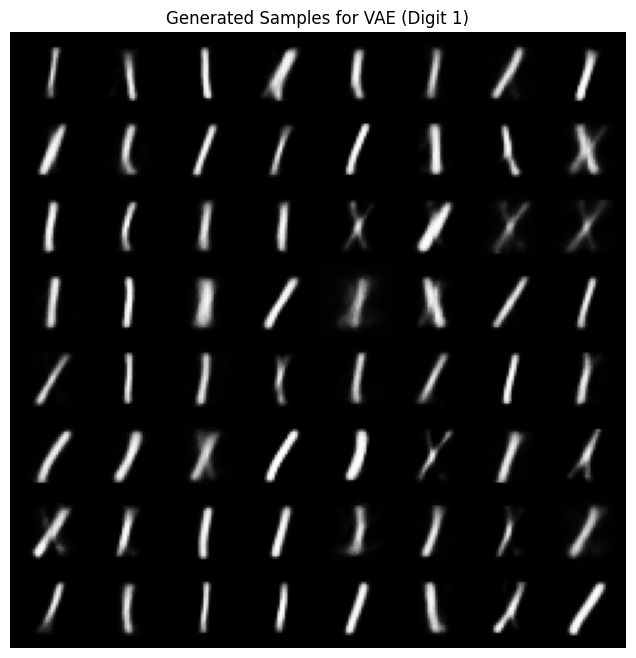


--- Training VAE for class/task 2 ---


VAE Epoch 1/10: 100%|██████████| 94/94 [00:00<00:00, 246.07it/s]


VAE Epoch 1, Average Loss: 236.3988


VAE Epoch 2/10: 100%|██████████| 94/94 [00:00<00:00, 250.00it/s]


VAE Epoch 2, Average Loss: 172.4507


...

VAE Epoch 9, Average Loss: 123.4601


VAE Epoch 10/10: 100%|██████████| 94/94 [00:00<00:00, 205.69it/s]


VAE Epoch 10, Average Loss: 121.6754
Saved VAE model for digit 2 to ./vae_models/vae_mnist_digit_2.pth


VAE Test for digit 2: 100%|██████████| 17/17 [00:00<00:00, 708.29it/s]

VAE Test Loss for digit 2: 120.6058


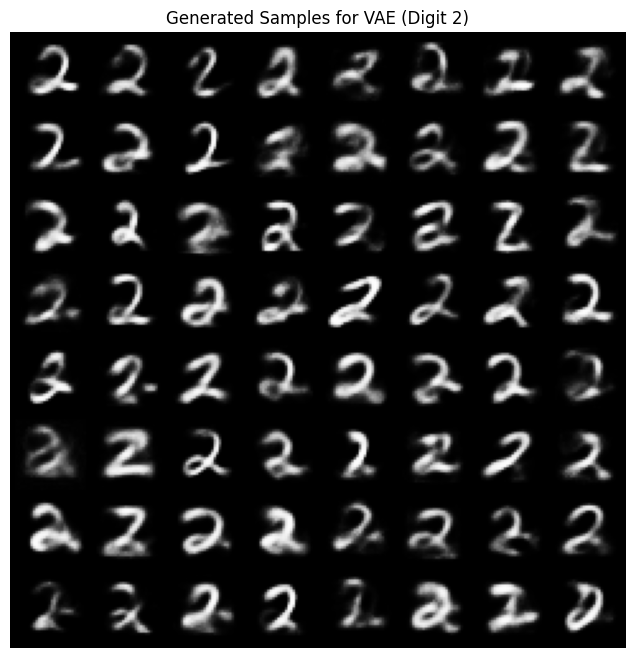


--- Training VAE for class/task 3 ---


VAE Epoch 1/10: 100%|██████████| 96/96 [00:00<00:00, 214.77it/s]


VAE Epoch 1, Average Loss: 218.1611


VAE Epoch 2/10: 100%|██████████| 96/96 [00:00<00:00, 246.79it/s]


VAE Epoch 2, Average Loss: 157.7431


...

VAE Epoch 9, Average Loss: 115.9947


VAE Epoch 10/10: 100%|██████████| 96/96 [00:00<00:00, 233.58it/s]


VAE Epoch 10, Average Loss: 114.4781
Saved VAE model for digit 3 to ./vae_models/vae_mnist_digit_3.pth


VAE Test for digit 3: 100%|██████████| 16/16 [00:00<00:00, 761.92it/s]


VAE Test Loss for digit 3: 113.1590


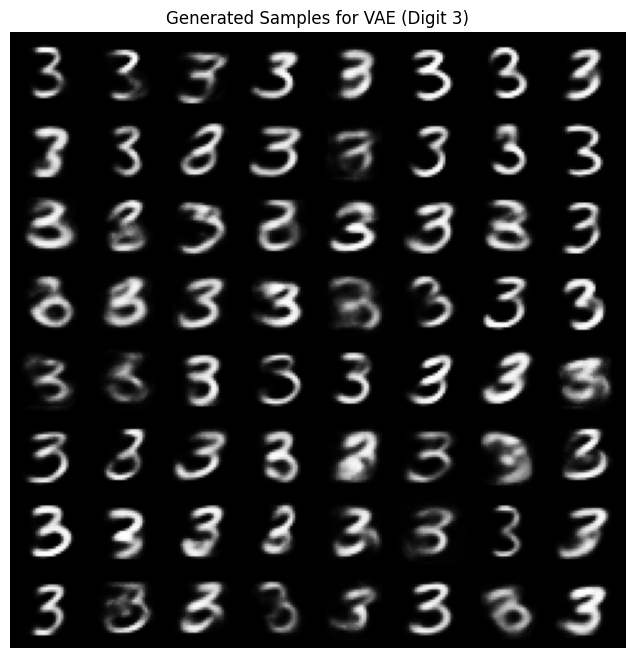


--- Training VAE for class/task 4 ---


VAE Epoch 1/10: 100%|██████████| 92/92 [00:00<00:00, 222.76it/s]


VAE Epoch 1, Average Loss: 210.2300


VAE Epoch 2/10: 100%|██████████| 92/92 [00:00<00:00, 199.13it/s]


VAE Epoch 2, Average Loss: 146.0968


...

VAE Epoch 9, Average Loss: 104.4883


VAE Epoch 10/10: 100%|██████████| 92/92 [00:00<00:00, 227.16it/s]


VAE Epoch 10, Average Loss: 102.8870
Saved VAE model for digit 4 to ./vae_models/vae_mnist_digit_4.pth


VAE Test for digit 4: 100%|██████████| 16/16 [00:00<00:00, 762.12it/s]


VAE Test Loss for digit 4: 101.7168


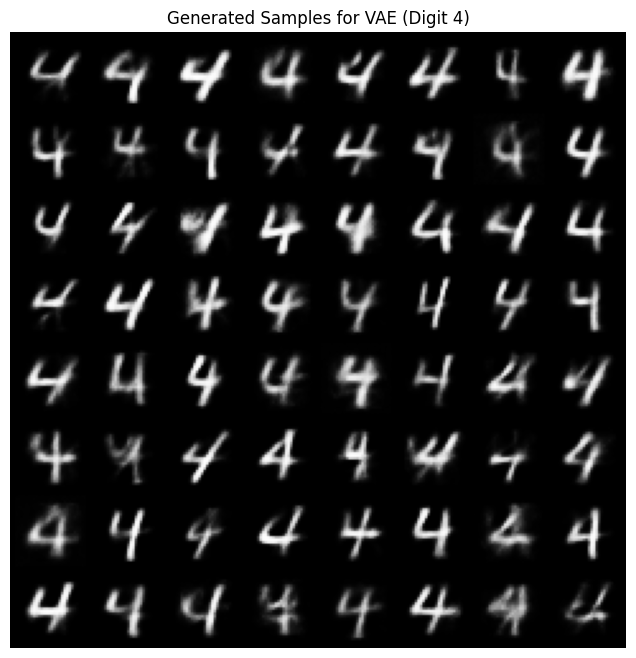


--- Training VAE for class/task 5 ---


VAE Epoch 1/10: 100%|██████████| 85/85 [00:00<00:00, 220.21it/s]


VAE Epoch 1, Average Loss: 226.0081


VAE Epoch 2/10: 100%|██████████| 85/85 [00:00<00:00, 244.23it/s]


VAE Epoch 2, Average Loss: 160.5981


...

VAE Epoch 9, Average Loss: 118.2717


VAE Epoch 10/10: 100%|██████████| 85/85 [00:00<00:00, 230.35it/s]


VAE Epoch 10, Average Loss: 116.4418
Saved VAE model for digit 5 to ./vae_models/vae_mnist_digit_5.pth


VAE Test for digit 5: 100%|██████████| 14/14 [00:00<00:00, 823.52it/s]


VAE Test Loss for digit 5: 116.2225


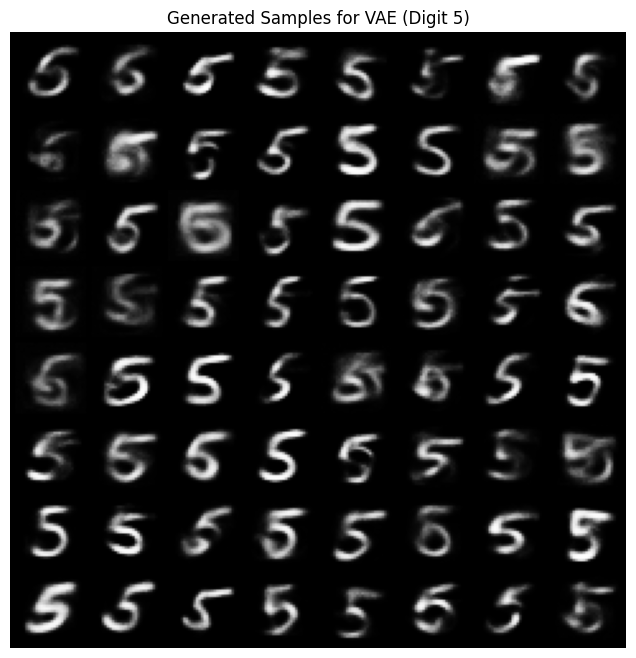


--- Training VAE for class/task 6 ---


VAE Epoch 1/10: 100%|██████████| 93/93 [00:00<00:00, 226.28it/s]


VAE Epoch 1, Average Loss: 209.3773


VAE Epoch 2/10: 100%|██████████| 93/93 [00:00<00:00, 210.88it/s]


VAE Epoch 2, Average Loss: 144.6693


...

VAE Epoch 9, Average Loss: 105.1573


VAE Epoch 10/10: 100%|██████████| 93/93 [00:00<00:00, 227.94it/s]


VAE Epoch 10, Average Loss: 103.6426
Saved VAE model for digit 6 to ./vae_models/vae_mnist_digit_6.pth


VAE Test for digit 6: 100%|██████████| 15/15 [00:00<00:00, 882.32it/s]


VAE Test Loss for digit 6: 105.8109


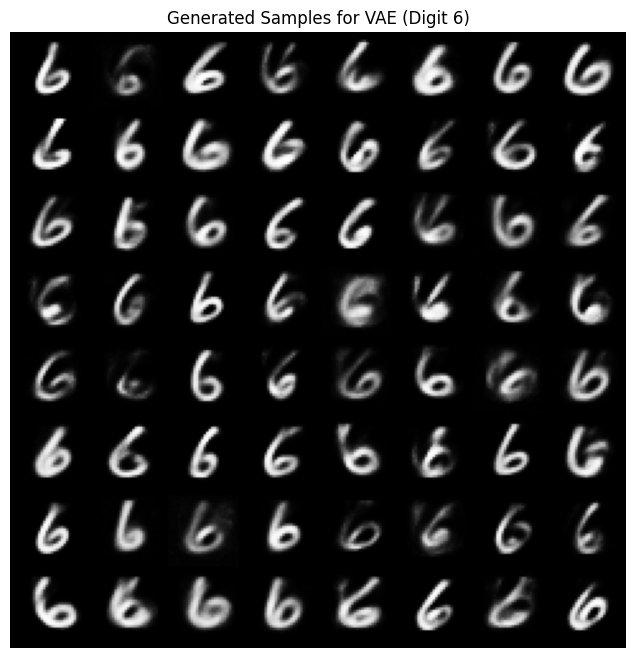


--- Training VAE for class/task 7 ---


VAE Epoch 1/10: 100%|██████████| 98/98 [00:00<00:00, 223.23it/s]


VAE Epoch 1, Average Loss: 193.6547


VAE Epoch 2/10: 100%|██████████| 98/98 [00:00<00:00, 239.61it/s]


VAE Epoch 2, Average Loss: 128.3965


...

VAE Epoch 9, Average Loss: 91.7947


VAE Epoch 10/10: 100%|██████████| 98/98 [00:00<00:00, 195.22it/s]


VAE Epoch 10, Average Loss: 90.5208
Saved VAE model for digit 7 to ./vae_models/vae_mnist_digit_7.pth


VAE Test for digit 7: 100%|██████████| 17/17 [00:00<00:00, 894.75it/s]


VAE Test Loss for digit 7: 90.3987


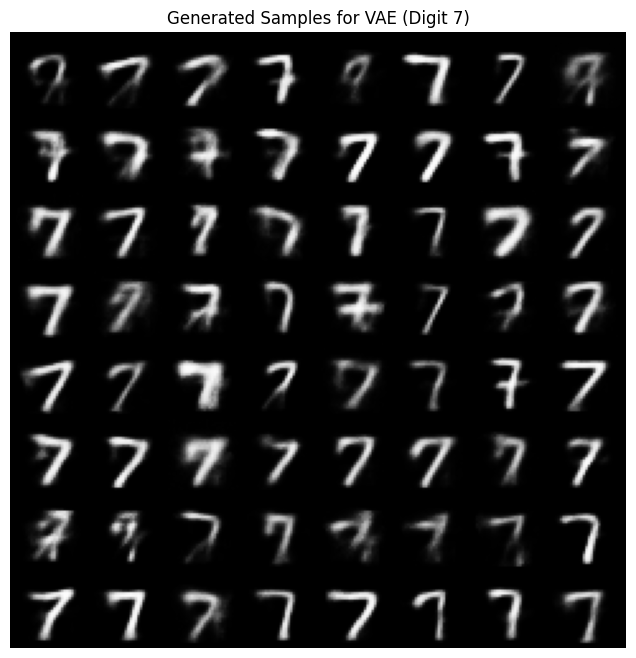


--- Training VAE for class/task 8 ---


VAE Epoch 1/10: 100%|██████████| 92/92 [00:00<00:00, 244.68it/s]


VAE Epoch 1, Average Loss: 226.1235


VAE Epoch 2/10: 100%|██████████| 92/92 [00:00<00:00, 246.65it/s]


VAE Epoch 2, Average Loss: 166.7631


...

VAE Epoch 9, Average Loss: 125.0988


VAE Epoch 10/10: 100%|██████████| 92/92 [00:00<00:00, 220.61it/s]


VAE Epoch 10, Average Loss: 123.4470
Saved VAE model for digit 8 to ./vae_models/vae_mnist_digit_8.pth


VAE Test for digit 8: 100%|██████████| 16/16 [00:00<00:00, 666.60it/s]


VAE Test Loss for digit 8: 124.5283


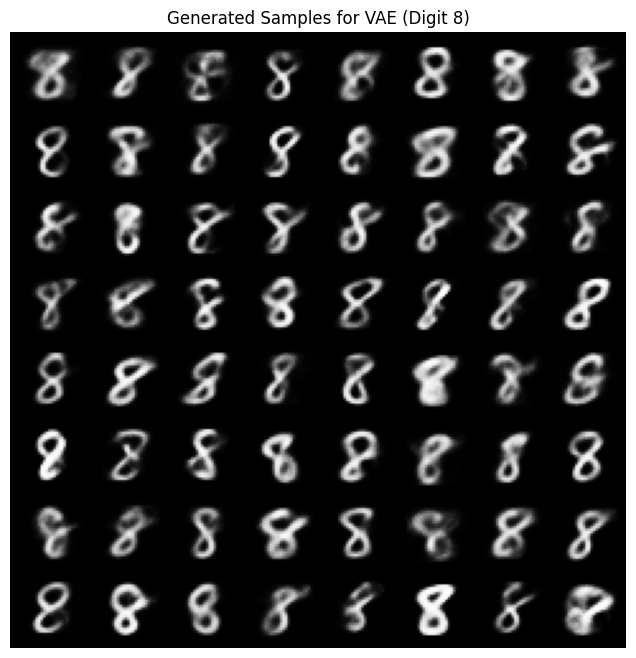


--- Training VAE for class/task 9 ---


VAE Epoch 1/10: 100%|██████████| 93/93 [00:00<00:00, 238.46it/s]


VAE Epoch 1, Average Loss: 196.4992


VAE Epoch 2/10: 100%|██████████| 93/93 [00:00<00:00, 240.92it/s]


VAE Epoch 2, Average Loss: 134.7310


...

VAE Epoch 9, Average Loss: 99.4630


VAE Epoch 10/10: 100%|██████████| 93/93 [00:00<00:00, 226.83it/s]


VAE Epoch 10, Average Loss: 98.0590
Saved VAE model for digit 9 to ./vae_models/vae_mnist_digit_9.pth


VAE Test for digit 9: 100%|██████████| 16/16 [00:00<00:00, 235.29it/s]

VAE Test Loss for digit 9: 97.2157


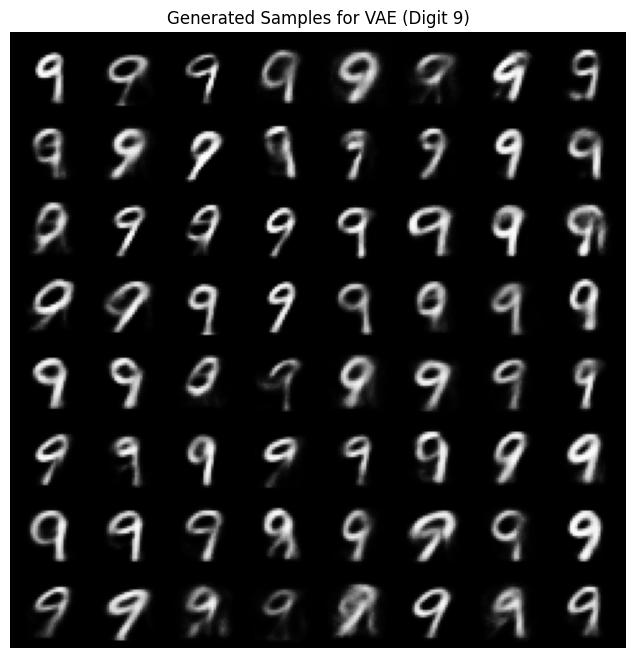

In [7]:
# Function to train the VAE model.
# train_data: dataset for training the VAE (e.g., data for a specific digit).
# test_data: dataset for testing the VAE after each epoch (optional, used here for consistency).
# t: identifier for the VAE (e.g., digit index), used for saving the model.
def train_vae(train_data=None, test_data=None, t=None, vae_latent_dim=20):
    # Hyperparameters for VAE training.
    input_dim_vae = config['size'] * config['size'] * config['channels'] # 28*28*1 = 784 for MNIST.
    hidden_dim_vae = 400  # Number of units in VAE's hidden layers.
    # latent_dim_vae is passed as argument, default 20. This is the 'output_dim' mentioned in original notebook for VAE.
    batch_size_vae = 64
    num_epochs_vae = 10 # Reduced from 5 for better VAEs, adjust as needed. Original was 5.
    learning_rate_vae = 1e-3

    # Create DataLoader for VAE training data.
    train_loader_vae = torch.utils.data.DataLoader(train_data, batch_size=batch_size_vae, shuffle=True)

    # Initialize VAE model, loss function (defined within VAE class), and optimizer.
    model_vae = VAE(input_dim_vae, hidden_dim_vae, vae_latent_dim)
    optimizer_vae = optim.Adam(model_vae.parameters(), lr=learning_rate_vae)

    print(f"\n--- Training VAE for class/task {t} ---")
    # Training loop.
    for epoch in range(num_epochs_vae):
        model_vae.train() # Set model to training mode.
        train_loss_vae = 0
        # Iterate over batches of training data.
        for batch_idx, (data_batch, _) in enumerate(tqdm(train_loader_vae, desc=f"VAE Epoch {epoch+1}/{num_epochs_vae}")):
            # Data is (batch_size, C, H, W). Flatten it for VAE's MLP structure.
            data_flat = data_batch.view(data_batch.size(0), -1)
            
            optimizer_vae.zero_grad() # Zero gradients.
            
            # Forward pass: get reconstruction, mu, and logvar.
            recon_batch_flat, mu, logvar = model_vae(data_flat) # model_vae input is already flattened by its forward method
            
            # Calculate VAE loss.
            loss_vae = model_vae.loss_function(data_flat, recon_batch_flat, mu, logvar)
            
            loss_vae.backward() # Backward pass: compute gradients.
            train_loss_vae += loss_vae.item() # Accumulate loss.
            optimizer_vae.step() # Update model parameters.

        # Print average training loss for the epoch.
        # len(train_loader_vae.dataset) is the total number of training samples.
        avg_epoch_loss = train_loss_vae / len(train_loader_vae.dataset)
        print(f'VAE Epoch {epoch + 1}, Average Loss: {avg_epoch_loss:.4f}')

    # Save the trained VAE model checkpoint.
    # The path includes './vae_models/' to store VAE models separately.
    torch.save(model_vae.state_dict(), f'./vae_models/vae_mnist_digit_{t}.pth')
    print(f"Saved VAE model for digit {t} to ./vae_models/vae_mnist_digit_{t}.pth")
    return model_vae

# Function to test the VAE model and visualize generated samples.
def test_vae(model_vae, test_data=None, batch_size_vae_test=64, t=None, vae_latent_dim=20):
    # Create DataLoader for VAE test data.
    test_loader_vae = torch.utils.data.DataLoader(test_data, batch_size=batch_size_vae_test, shuffle=False)
    
    # Load the model checkpoint (optional if model is passed directly after training).
    # model_vae.load_state_dict(torch.load(f'./vae_models/vae_mnist_digit_{t}.pth'))
    
    model_vae.eval() # Set model to evaluation mode.
    test_loss_vae = 0
    with torch.no_grad(): # Disable gradient calculations.
        for batch_idx, (data_batch, _) in enumerate(tqdm(test_loader_vae, desc=f"VAE Test for digit {t}")):
            data_flat = data_batch.view(data_batch.size(0), -1)
            recon_batch_flat, mu, logvar = model_vae(data_flat)
            loss_vae = model_vae.loss_function(data_flat, recon_batch_flat, mu, logvar)
            test_loss_vae += loss_vae.item()

    avg_test_loss = test_loss_vae / len(test_loader_vae.dataset)
    print(f'VAE Test Loss for digit {t}: {avg_test_loss:.4f}')

    # Generate and display sample images from the VAE.
    # num_generated_samples: how many samples to generate (e.g., 64 for an 8x8 grid).
    num_generated_samples = 64
    # latent_dim is needed for the generate method.
    samples = model_vae.generate(num_generated_samples, latent_dim=vae_latent_dim)
    # make_grid arranges images into a grid for visualization.
    grid = make_grid(samples, nrow=8) # nrow specifies number of images per row.
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy()) # permute to change (C,H,W) to (H,W,C) for imshow.
    plt.title(f"Generated Samples for VAE (Digit {t})")
    plt.axis('off')
    plt.show()

# Define VAE parameters (consistent with train_vae defaults if not overridden).
vae_input_dim = config['size'] * config['size'] * config['channels']
vae_hidden_dim = 400
vae_latent_dim = 20 # This is the 'output_dim' for VAE's latent space.

# List to store trained VAE models, one for each digit.
trained_vaes = []
print("\n--- Training VAEs for Each Digit ---")
for i in range(num_digits): # num_digits is 10 (for 0-9)
    # train_data_per_digit[i] contains data only for digit 'i'.
    # test_data_per_digit[i] contains test data only for digit 'i'.
    vae_model_for_digit = train_vae(train_data=train_data_per_digit[i], 
                                    test_data=test_data_per_digit[i], 
                                    t=i, 
                                    vae_latent_dim=vae_latent_dim)
    trained_vaes.append(vae_model_for_digit)
    # Test the VAE and visualize generated samples.
    test_vae(vae_model_for_digit, 
             test_data=test_data_per_digit[i], 
             t=i, 
             vae_latent_dim=vae_latent_dim)


#### Populate Replay Buffer with your generated samples

For each of these use cases, we will adopt reservoir sampling. We first fix the size of the memory buffer to N samples, for instance 10000. The idea is that at each time step, we should save equal number of samples for each of the previously seen class instances.

If you recall, each of our contexts has only 2 class labels.
So, at the end of the first task, we will store 5000 samples from labels [0] and [1].
Similarily at the end of the second task, we will store 2500 samples from labels [0], [1], [2], [3]
Continue it till the final context

Replay buffer for each context should look this:
- context_0: [5000, 5000] (Replay buffer created *after* context 0, for use when training context 1)
- context_1: [2500, 2500, 2500, 2500] (Replay buffer created *after* context 1, for use when training context 2)
- context_2:[1666, 1666, 1666, 1666, 1666, 1666] (Approx. for 10000 / 6)
- context_3: [1250, 1250, 1250, 1250, 1250, 1250, 1250, 1250]




In [8]:
# Define the main VAE model structure (can be a dummy instance if only using trained_vaes list).
# This generator instance is not strictly needed if we load models by path or use the trained_vaes list.
# However, if methods like 'generate' are on a specific instance, ensure it's correctly parameterized.
# For simplicity, we will use the models from the 'trained_vaes' list directly.

mem_size_generative = 10000  # Total size of the replay buffer.
num_contexts_for_replay = num_contexts -1 # Replay buffers are needed for contexts 1 through num_contexts-1 (i.e. 4 buffers)

generative_replay_buffers = [] # A list to store replay buffers for each step.
                               # generative_replay_buffers[i] will be the buffer created after context i, used for training context i+1.

print(f"\n--- Populating Generative Replay Buffers (Total Size: {mem_size_generative}) ---")
# Loop to create replay buffers. We need num_contexts-1 replay buffers.
# The i-th replay buffer is created after training context i, and contains samples from classes 0 to i.
for i in range(num_contexts_for_replay): # i will go from 0 to 3
    current_replay_buffer = []
    # Determine the classes seen so far (up to context i).
    # labels_per_context_train defines classes for each context: [[0,1], [2,3], ...]
    # labels_per_context_test defines cumulative classes: [[0,1], [0,1,2,3], ...]
    # We need classes from labels_per_context_test[i] for the i-th replay buffer.
    classes_in_this_replay = labels_per_context_test[i] # These are the classes from all previously seen contexts.
    num_distinct_classes = len(classes_in_this_replay)
    
    if num_distinct_classes == 0:
        generative_replay_buffers.append([]) # No classes seen yet (should not happen for i >= 0)
        continue
        
    # Calculate number of samples to generate per class.
    # Ensure roughly equal distribution, handle potential rounding.
    samples_per_class = mem_size_generative // num_distinct_classes
    print(f"Replay Buffer {i} (for training Context {i+1}): Storing {samples_per_class} samples for each of {num_distinct_classes} classes: {classes_in_this_replay}")

    for class_label in classes_in_this_replay:
        # Retrieve the VAE trained for this specific class_label.
        # trained_vaes is a list where trained_vaes[j] is the VAE for digit j.
        vae_for_class = trained_vaes[class_label]
        vae_for_class.eval() # Ensure VAE is in evaluation mode.
        
        # Generate samples using the VAE for the current class_label.
        # vae_latent_dim is the latent dimension used during VAE training.
        generated_samples_for_class = vae_for_class.generate(num_samples=samples_per_class, latent_dim=vae_latent_dim)
        
        # Add the generated samples (image, label) to the current replay buffer.
        for sample_idx in range(generated_samples_for_class.size(0)):
            # The label should be the class_label for which samples were generated.
            current_replay_buffer.append((generated_samples_for_class[sample_idx], class_label))
            
    # Shuffle the replay buffer to mix samples from different classes.
    random.shuffle(current_replay_buffer)
    generative_replay_buffers.append(current_replay_buffer)
    print(f"Replay Buffer {i} created with {len(current_replay_buffer)} generated samples.")

# Check the size of the first generative replay buffer
if len(generative_replay_buffers) > 0:
    print(f"Size of first generative replay buffer (for Context 1): {len(generative_replay_buffers[0])}")



--- Populating Generative Replay Buffers (Total Size: 10000) ---
Replay Buffer 0 (for training Context 1): Storing 5000 samples for each of 2 classes: [0, 1]
Replay Buffer 0 created with 10000 generated samples.
Replay Buffer 1 (for training Context 2): Storing 2500 samples for each of 4 classes: [0, 1, 2, 3]
Replay Buffer 1 created with 10000 generated samples.
Replay Buffer 2 (for training Context 3): Storing 1666 samples for each of 6 classes: [0, 1, 2, 3, 4, 5]
Replay Buffer 2 created with 9996 generated samples.
Replay Buffer 3 (for training Context 4): Storing 1250 samples for each of 8 classes: [0, 1, 2, 3, 4, 5, 6, 7]
Replay Buffer 3 created with 10000 generated samples.
Size of first generative replay buffer (for Context 1): 10000


In [9]:
# Re-initialize a new classifier model for training with generative replay.
model_generative_replay = Classifier(hidden_dim=256, output_dim=10)
accuracies_generative_replay = []

print("\n--- Training Classifier Sequentially with Generative Replay ---")
for i in range(num_contexts): # Iterate through each context (0 to 4)
    print(f"\nTraining on Context {i} (Labels: {labels_per_context_train[i]}) with Generative Replay")
    
    # Get the training data for the current context.
    current_task_train_data = train_data_cl[i]
    
    # For the first context (i=0), there is no replay buffer yet.
    if i == 0:
        combined_train_data = current_task_train_data
    else:
        # For subsequent contexts, combine current task data with the replay buffer.
        # generative_replay_buffers[i-1] is the buffer created after context i-1.
        replay_data_to_use = generative_replay_buffers[i-1]
        print(f"Using generative replay buffer of size {len(replay_data_to_use)} for context {i}")
        combined_train_data = current_task_train_data + replay_data_to_use
    
    # Train the classifier on the combined data.
    # Evaluate on the cumulative test set for the current context (test_data_cl[i]).
    train_classifier(model_generative_replay, combined_train_data, test_data_cl[i], 
                     num_epochs=5, batch_size=64, learning_rate=0.01) # Original notebook: num_epochs=10 for replay, lr=0.1. Adjusted for consistency/speed.
    
    # Optionally save the model state.
    # torch.save(model_generative_replay.state_dict(), f'./model_replay/generative_replay_context_{i}.pth')

# Evaluate the final model (after training with generative replay) on all context test sets.
print("\n--- Evaluating Final Model (Generative Replay) on All Context Test Sets ---")
for i in range(num_contexts):
    acc = evaluate_classifier(model_generative_replay, i, test_data_cl[i], batch_size=32)
    accuracies_generative_replay.append(acc)
print(f"\nAverage accuracy across all context evaluations (Generative Replay): {np.mean(accuracies_generative_replay):.2f}%")


--- Training Classifier Sequentially with Generative Replay ---

Training on Context 0 (Labels: [0, 1]) with Generative Replay


Epoch 1/5 Training: 100%|██████████| 198/198 [00:03<00:00, 65.58it/s]


Epoch [1/5], Loss: 0.3826


Epoch 2/5 Training: 100%|██████████| 198/198 [00:02<00:00, 74.16it/s]


Epoch [2/5], Loss: 0.0247


...

Accuracy of the model on test data for Context 2 (Labels: [0, 1, 2, 3, 4, 5]): 88.82%


Evaluating on Context 3: 100%|██████████| 251/251 [00:00<00:00, 309.46it/s]


Accuracy of the model on test data for Context 3 (Labels: [0, 1, 2, 3, 4, 5, 6, 7]): 87.58%


Evaluating on Context 4: 100%|██████████| 313/313 [00:01<00:00, 304.17it/s]

Accuracy of the model on test data for Context 4 (Labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]): 89.70%

Average accuracy across all context evaluations (Generative Replay): 90.40%


#### Experience Replay

Now, we could perform the similar experiments with real data samples directly from the dataset. Use the same reservoir sampling approach to populate the replay buffer

In [10]:
mem_size_experience = 10000 # Total size of the experience replay buffer.

# This 'labels_for_er_definition' defines which classes should be in the replay buffer *after* a certain context is trained.
# labels_for_er_definition[i] contains the list of classes that should be in the replay buffer
# created *after* context 'i' has been trained. This buffer will be used when training context 'i+1'.
# Example: labels_for_er_definition[0] = [[0],[1]] means after context 0 (labels 0,1), the replay buffer should contain samples of 0 and 1.
labels_for_er_definition = [
    [[0],[1]],                         # After context 0 (labels 0,1 trained), replay these for context 1 training.
    [[0],[1],[2],[3]],                 # After context 1 (labels 2,3 trained), replay these for context 2 training.
    [[0],[1],[2],[3],[4],[5]],         # After context 2 (labels 4,5 trained), replay these for context 3 training.
    [[0],[1],[2],[3],[4],[5],[6],[7]]  # After context 3 (labels 6,7 trained), replay these for context 4 training.
]

experience_replay_buffers = {} # Using a dictionary for experience replay buffers, keyed by context index.
                               # e.g., experience_replay_buffers[f'context_{i}'] is buffer created after context i.

print(f"\n--- Populating Experience Replay Buffers (Total Size: {mem_size_experience}) ---")
# Loop to create num_contexts-1 replay buffers.
for i in range(num_contexts_for_replay): # i from 0 to 3
    current_er_buffer = []
    # Get the list of class labels that should be in this replay buffer.
    # labels_for_er_definition[i] is a list of lists, e.g., [[0],[1]]. Flatten it.
    classes_for_this_er = [label_item[0] for label_item in labels_for_er_definition[i]]
    num_distinct_classes_er = len(classes_for_this_er)

    if num_distinct_classes_er == 0:
        experience_replay_buffers[f'context_{i}'] = []
        continue
        
    samples_per_class_er = mem_size_experience // num_distinct_classes_er
    print(f"Experience Replay Buffer for training Context {i+1}: Storing {samples_per_class_er} real samples for each of {num_distinct_classes_er} classes: {classes_for_this_er}")

    for class_label in classes_for_this_er:
        # Collect all samples of 'class_label' from the original mnist_trainset.
        samples_of_class = [sample for sample in mnist_trainset if sample[1] == class_label]
        
        # Randomly select 'samples_per_class_er' samples for this class.
        # If fewer samples are available than needed, take all available samples.
        num_to_sample = min(len(samples_of_class), samples_per_class_er)
        selected_samples = random.sample(samples_of_class, num_to_sample)
        current_er_buffer.extend(selected_samples)
    
    random.shuffle(current_er_buffer) # Shuffle the collected samples.
    experience_replay_buffers[f'context_{i}'] = current_er_buffer
    print(f"Experience Replay Buffer for training Context {i+1} created with {len(current_er_buffer)} real samples.")

# Check the size of the first experience replay buffer
if f'context_0' in experience_replay_buffers:
    print(f"Size of first experience replay buffer (for Context 1): {len(experience_replay_buffers[f'context_0'])}")


--- Populating Experience Replay Buffers (Total Size: 10000) ---
Experience Replay Buffer for training Context 1: Storing 5000 real samples for each of 2 classes: [0, 1]
Experience Replay Buffer for training Context 1 created with 10000 real samples.
Experience Replay Buffer for training Context 2: Storing 2500 real samples for each of 4 classes: [0, 1, 2, 3]
Experience Replay Buffer for training Context 2 created with 10000 real samples.
Experience Replay Buffer for training Context 3: Storing 1666 real samples for each of 6 classes: [0, 1, 2, 3, 4, 5]
Experience Replay Buffer for training Context 3 created with 9996 real samples.
Experience Replay Buffer for training Context 4: Storing 1250 real samples for each of 8 classes: [0, 1, 2, 3, 4, 5, 6, 7]
Experience Replay Buffer for training Context 4 created with 10000 real samples.
Size of first experience replay buffer (for Context 1): 10000


#### Train all the contexts using replay buffer

In [11]:
# Re-initialize a new classifier model for training with experience replay.
model_experience_replay = Classifier(hidden_dim=256, output_dim=10)
accuracies_experience_replay = []

print("\n--- Training Classifier Sequentially with Experience Replay ---")
for i in range(num_contexts): # Iterate through each context (0 to 4)
    print(f"\nTraining on Context {i} (Labels: {labels_per_context_train[i]}) with Experience Replay")
    
    current_task_train_data = train_data_cl[i]
    
    if i == 0:
        combined_train_data_er = current_task_train_data
    else:
        # Retrieve the experience replay buffer created after context i-1.
        # The key is f'context_{i-1}' as per the population logic.
        replay_data_to_use_er = experience_replay_buffers.get(f'context_{i-1}', [])
        print(f"Using experience replay buffer of size {len(replay_data_to_use_er)} for context {i}")
        combined_train_data_er = current_task_train_data + replay_data_to_use_er
    
    # Train the classifier on the combined data.
    train_classifier(model_experience_replay, combined_train_data_er, test_data_cl[i], 
                     num_epochs=5, batch_size=64, learning_rate=0.01) # Original: num_epochs=10 for replay, lr=0.1. Adjusted.
    
    # Optionally save the model state.
    # torch.save(model_experience_replay.state_dict(), f'./model_replay/experience_replay_context_{i}.pth')

# Evaluate the final model (after training with experience replay) on all context test sets.
print("\n--- Evaluating Final Model (Experience Replay) on All Context Test Sets ---")
for i in range(num_contexts):
    acc = evaluate_classifier(model_experience_replay, i, test_data_cl[i], batch_size=32)
    accuracies_experience_replay.append(acc)
print(f"\nAverage accuracy across all context evaluations (Experience Replay): {np.mean(accuracies_experience_replay):.2f}%")

# Final comparison of average accuracies
print("\n--- Summary of Average Accuracies ---")
if 'accuracies_no_replay' in locals() and accuracies_no_replay:
    print(f"Average accuracy (No Replay): {np.mean(accuracies_no_replay):.2f}%")
if 'accuracies_generative_replay' in locals() and accuracies_generative_replay:
    print(f"Average accuracy (Generative Replay): {np.mean(accuracies_generative_replay):.2f}%")
if 'accuracies_experience_replay' in locals() and accuracies_experience_replay:
    print(f"Average accuracy (Experience Replay): {np.mean(accuracies_experience_replay):.2f}%")


--- Training Classifier Sequentially with Experience Replay ---

Training on Context 0 (Labels: [0, 1]) with Experience Replay


Epoch 1/5 Training: 100%|██████████| 198/198 [00:02<00:00, 74.72it/s]


Epoch [1/5], Loss: 0.4643


Epoch 2/5 Training: 100%|██████████| 198/198 [00:02<00:00, 76.57it/s]


Epoch [2/5], Loss: 0.0252


...

Accuracy of the model on test data for Context 2 (Labels: [0, 1, 2, 3, 4, 5]): 94.94%


Evaluating on Context 3: 100%|██████████| 251/251 [00:00<00:00, 328.53it/s]


Accuracy of the model on test data for Context 3 (Labels: [0, 1, 2, 3, 4, 5, 6, 7]): 94.55%


Evaluating on Context 4: 100%|██████████| 313/313 [00:00<00:00, 332.63it/s]

Accuracy of the model on test data for Context 4 (Labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]): 95.17%

Average accuracy across all context evaluations (Experience Replay): 95.72%

--- Summary of Average Accuracies ---
Average accuracy (No Replay): 3.91%
Average accuracy (Generative Replay): 90.40%
Average accuracy (Experience Replay): 95.72%
